# Perceived stress and parenthood

**A report submitted for review.**

This analysis investigates whether respondents who have children differ from
those who do not in their level of perceived stress. The data are from a survey
of members of the general public in Melbourne, Australia, measuring a range of
wellbeing constructs on validated scales.

In [1]:
import math9102 as m9
import numpy as np
import pandas as pd
from scipy import stats

m9.use_house_style()

## 1. The data

In [2]:
survey = m9.load_survey()
survey.shape

(439, 134)

analysing 432 of 439 respondents


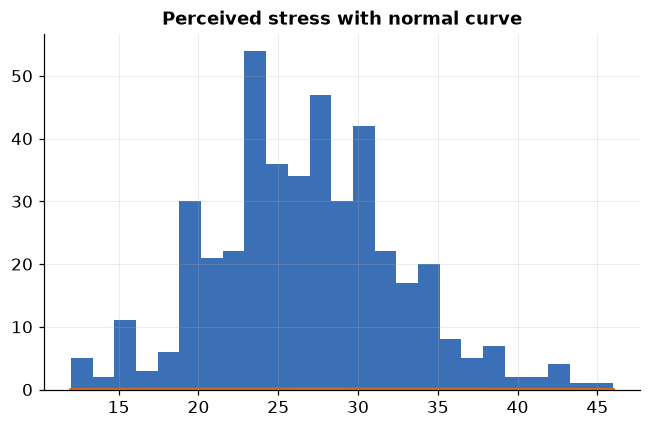

In [3]:
analysis = survey[["tpstress", "child"]].dropna()
print(f"analysing {len(analysis)} of {len(survey)} respondents")

# Check the shape of the outcome against a normal curve.
import matplotlib.pyplot as plt

x = analysis.tpstress
grid = np.linspace(x.min(), x.max(), 200)
curve = stats.norm.pdf(grid, x.mean(), x.std(ddof=1))

plt.hist(x, bins=25)
plt.plot(grid, curve, linewidth=2)
plt.title("Perceived stress with normal curve")
plt.show()

# The normal curve sits flat against the axis, so the data are
# clearly not normally distributed.

## 2. Hypotheses

> **H₀:** There is no difference in perceived stress between respondents who
> have children and those who do not.
>
> **H₁:** There is a difference in perceived stress between respondents who have
> children and those who do not.

Two-tailed, with α set at .05.

## 3. Describing the variables

In [4]:
m9.frequency(analysis, "child")

,count,percent,valid_percent
child,,,
NO,249,57.64,57.64
YES,183,42.36,42.36


In [5]:
m9.describe_by(analysis, "tpstress", "child")

,n,missing,mean,sd,se,median,iqr,min,max,skew,kurtosis
child,,,,,,,,,,,
NO,249.0,0.0,27.036,6.134,0.389,27.0,8.0,12.0,46.0,0.180,0.173
YES,183.0,0.0,26.339,5.425,0.401,26.0,7.5,13.0,42.0,0.303,0.131


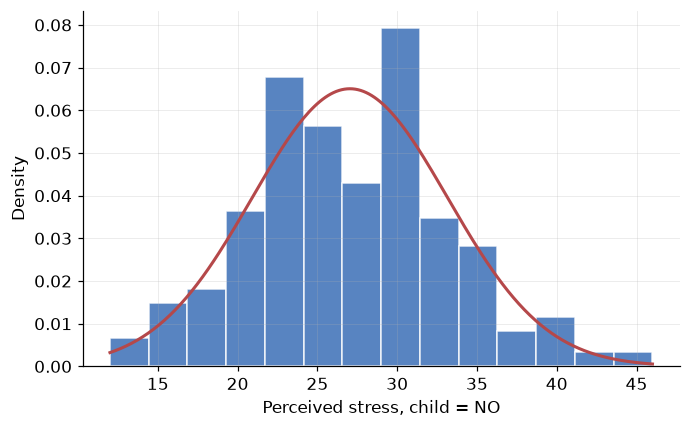

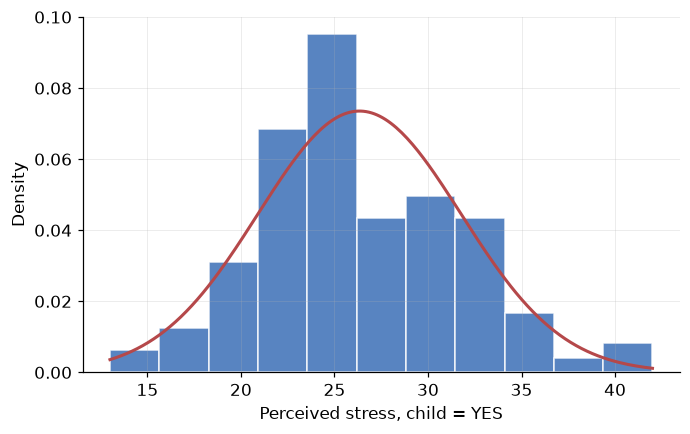

In [6]:
for level in ["NO", "YES"]:
    m9.histogram_with_normal(analysis.loc[analysis.child == level, "tpstress"],
                             xlabel=f"Perceived stress, child = {level}")

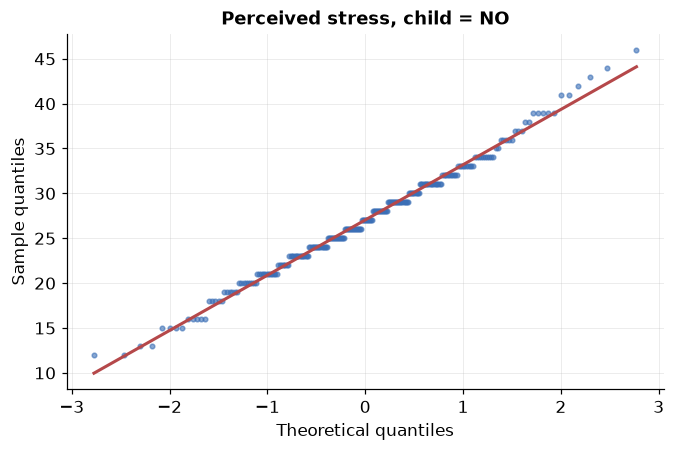

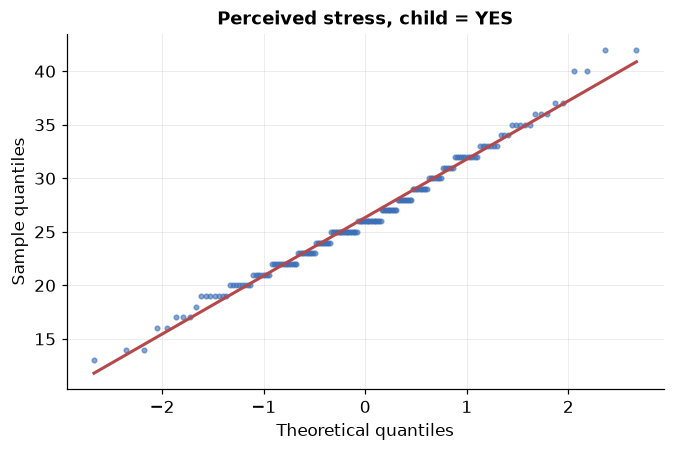

In [7]:
for level in ["NO", "YES"]:
    m9.qq_plot(analysis.loc[analysis.child == level, "tpstress"],
               title=f"Perceived stress, child = {level}")

Both distributions are single-peaked and close to symmetric, and the Q–Q
plots follow the reference line closely through the middle with only minor
departure at the extremes. With 432 respondents the standardised
shape statistics are highly sensitive to departures too small
to matter, so the judgement rests on the plots. Both groups were treated as
sufficiently close to normal for a parametric test.

## 4. Choosing the test

In [8]:
no = analysis.loc[analysis.child == "NO", "tpstress"]
yes = analysis.loc[analysis.child == "YES", "tpstress"]

levene = stats.levene(no, yes, center="median")
print(f"Levene: F = {levene.statistic:.4f}, p = {levene.pvalue:.5f}")

Levene: F = 3.1842, p = 0.07506


In [9]:
# Choose the test based on the outcome of Levene's test.
if levene.pvalue < 0.05:
    result = stats.ttest_ind(no, yes, equal_var=False)
    print("variances unequal - using Welch")
else:
    result = stats.ttest_ind(no, yes, equal_var=True)
    print("variances equal - using the pooled test")
print(f"t = {result.statistic:.4f}, p = {result.pvalue:.4f}")

variances equal - using the pooled test
t = 1.2254, p = 0.2211


## 5. Effect size

In [10]:
d = m9.cohens_d(no, yes)
print(f"Cohen's d = {d:.4f} ({m9.interpret(d, 'd')})")

Cohen's d = 0.1193 (negligible)


## 6. Results

An independent-samples *t*-test compared perceived stress between
respondents with and without children. Respondents without children
(*M* = 27.04, *SD* = 6.13, *n* = 249) scored
slightly higher than respondents with children (*M* = 26.34,
*SD* = 5.43, *n* = 183). The difference was not
statistically significant, *t*(430.00) = 1.23,
*p* = 0.221, *n* = 430. Cohen's *d* was 0.12, a
negligible effect.

## 7. Conclusion

There is insufficient evidence to reject the null hypothesis. This does
not establish that the two groups are the same; it means this sample did
not provide sufficient evidence of a difference. The difference this
sample shows is negligible in size.

---

*Analysis prepared using Python 3.12, pandas and scipy. Guidance on the choice
and interpretation of statistical tests follows Field, Miles and Field (2012).*